<a href="https://colab.research.google.com/github/nabillahumi/S5-Mesin_Learning/blob/main/Jobsheet6%20Regresi/Praktikum%202%20(JS6R).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mengimpor Library

In [1]:
# Mengimpor library
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Mengimpor Dataset

In [2]:
# Mengimpor dataset (Pastikan Anda memiliki file CSV 'Posisi_gaji.csv' dalam direktori yang sama)
dataset = pd.read_csv('Posisi_gaji.csv')
X = dataset.iloc[:, 1:2].values
y = dataset.iloc[:, 2].values  # Ubah menjadi satu kolom saja

#Feature Scaling

In [3]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X = sc_X.fit_transform(X.reshape(-1, 1))
y = sc_y.fit_transform(y.reshape(-1, 1))

#Fitting SVR ke Dataset

In [8]:
# Fitting SVR ke dataset
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X, y.ravel())

SVR()

#Visualisasi Hasil SVR:

/tmp/ipykernel_3612/3273719623.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


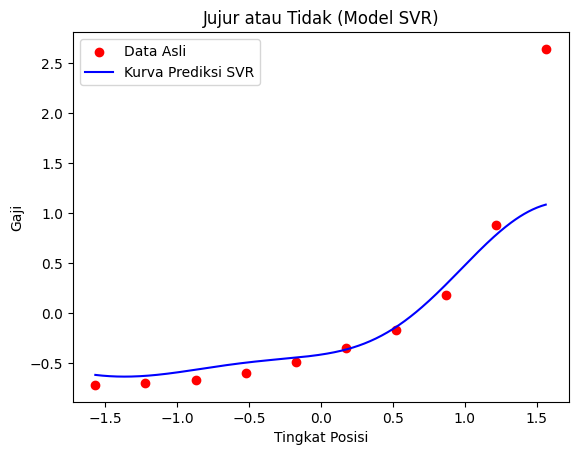

In [11]:
# Visualisasi hasil prediksi SVR
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)

plt.scatter(X, y, color='red', label='Data Asli')
plt.plot(X_grid, regressor.predict(X_grid), color='blue', label='Kurva Prediksi SVR')
plt.title('Jujur atau Tidak (Model SVR)')
plt.xlabel('Tingkat Posisi')
plt.ylabel('Gaji')
plt.legend()
plt.show()

#Prediksi Hasil:

In [12]:
# Membuat array 2D untuk tingkat posisi 6.5
tingkat_posisi_prediksi = np.array([[6.5]])

# Penskalaan data masukan prediksi
tingkat_posisi_prediksi_scaled = sc_X.transform(tingkat_posisi_prediksi)

# Melakukan prediksi nilai gaji dalam skala standar
gaji_prediksi_scaled = regressor.predict(tingkat_posisi_prediksi_scaled)

# Mengembalikan hasil prediksi ke skala nilai asli
gaji_prediksi = sc_y.inverse_transform(gaji_prediksi_scaled.reshape(-1, 1))

#Menampilkan Hasil:

In [7]:
# Menampilkan hasil prediksi
print("Prediksi Gaji untuk Tingkat Posisi 6.5:", gaji_prediksi[0])

Prediksi Gaji untuk Tingkat Posisi 6.5: [170370.0204065]


#Validasi Hasil

/tmp/ipykernel_3612/3273719623.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


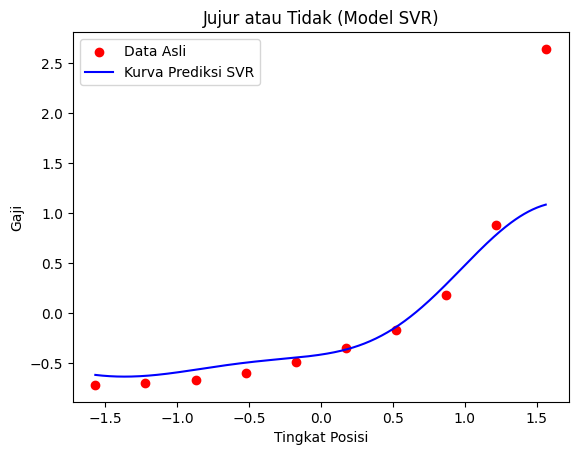

In [17]:
# Visualisasi hasil prediksi SVR
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)

plt.scatter(X, y, color='red', label='Data Asli')
plt.plot(X_grid, regressor.predict(X_grid), color='blue', label='Kurva Prediksi SVR')
plt.title('Jujur atau Tidak (Model SVR)')
plt.xlabel('Tingkat Posisi')
plt.ylabel('Gaji')
plt.legend()
plt.show()

#Evaluasi Model SVR

In [14]:
# Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_actual = y
y_pred = regressor.predict(X)

# Menghitung MAE
mae = mean_absolute_error(y_actual, y_pred)

# Menghitung MSE
mse = mean_squared_error(y_actual, y_pred)

# Menghitung RMSE
rmse = np.sqrt(mse)

# Menghitung R-squared
r2 = r2_score(y_actual, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R-squared:", r2)

MAE: 0.22299274095734414
MSE: 0.24839989293792014
RMSE: 0.4983973243687411
R-squared: 0.7516001070620798
